## 0. Install Dependencies

## 1. Configuration

In [68]:
import os

STRIPS_DIR  = '/Users/alyrajan/Desktop/Mudd/Computer Science/CS158 Project/MLProjectSp26/Data/Training/Strips'
MASKS_DIR   = '/Users/alyrajan/Desktop/Mudd/Computer Science/CS158 Project/MLProjectSp26/Data/Training/Masks'
MODEL_PATH  = '/Users/alyrajan/Desktop/Mudd/Computer Science/CS158 Project/MLProjectSp26/best_model.pt'

os.makedirs(STRIPS_DIR, exist_ok=True)
os.makedirs(MASKS_DIR,  exist_ok=True)

IMG_HEIGHT   = 256
IMG_WIDTH    = 1024
BATCH_SIZE   = 8
NUM_EPOCHS   = 50
LR           = 1e-4
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.05
RANDOM_SEED  = 42

# ── Model ─────────────────────────────────────────────────────────────────
ENCODER      = 'resnet34' # pretrained encoder
ENCODER_WEIGHTS = 'imagenet' # ImageNet pretrained weights

import torch
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: mps


In [69]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

def generate_mask(img_bgr: np.ndarray) -> np.ndarray:
    """
    Generate a binary mask from an ECG strip image.
    """
    b, g, r = cv2.split(img_bgr)

    # Isolate near-black pixels
    black_mask = ((b < 80) & (g < 80) & (r < 80)).astype(np.uint8) * 255

    # Close small gaps in the signal, remove isolated noise
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    kernel_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    mask = cv2.morphologyEx(black_mask, cv2.MORPH_CLOSE, kernel_close, iterations=2)
    mask = cv2.morphologyEx(mask,       cv2.MORPH_OPEN,  kernel_open,  iterations=1)

    return mask


strip_paths = list(Path(STRIPS_DIR).glob('*.png')) + list(Path(STRIPS_DIR).glob('*.jpg'))
print(f'Found {len(strip_paths)} strips')

for strip_path in tqdm(strip_paths, desc='Generating masks'):
    img  = cv2.imread(str(strip_path))
    mask = generate_mask(img)
    out_path = Path(MASKS_DIR) / (strip_path.stem + '_mask.png')
    cv2.imwrite(str(out_path), mask)

print('Done — masks saved to', MASKS_DIR)

Found 2400 strips


Generating masks: 100%|██████████| 2400/2400 [00:20<00:00, 117.98it/s]

Done — masks saved to /Users/alyrajan/Desktop/Mudd/Computer Science/CS158 Project/MLProjectSp26/Data/Training/Masks


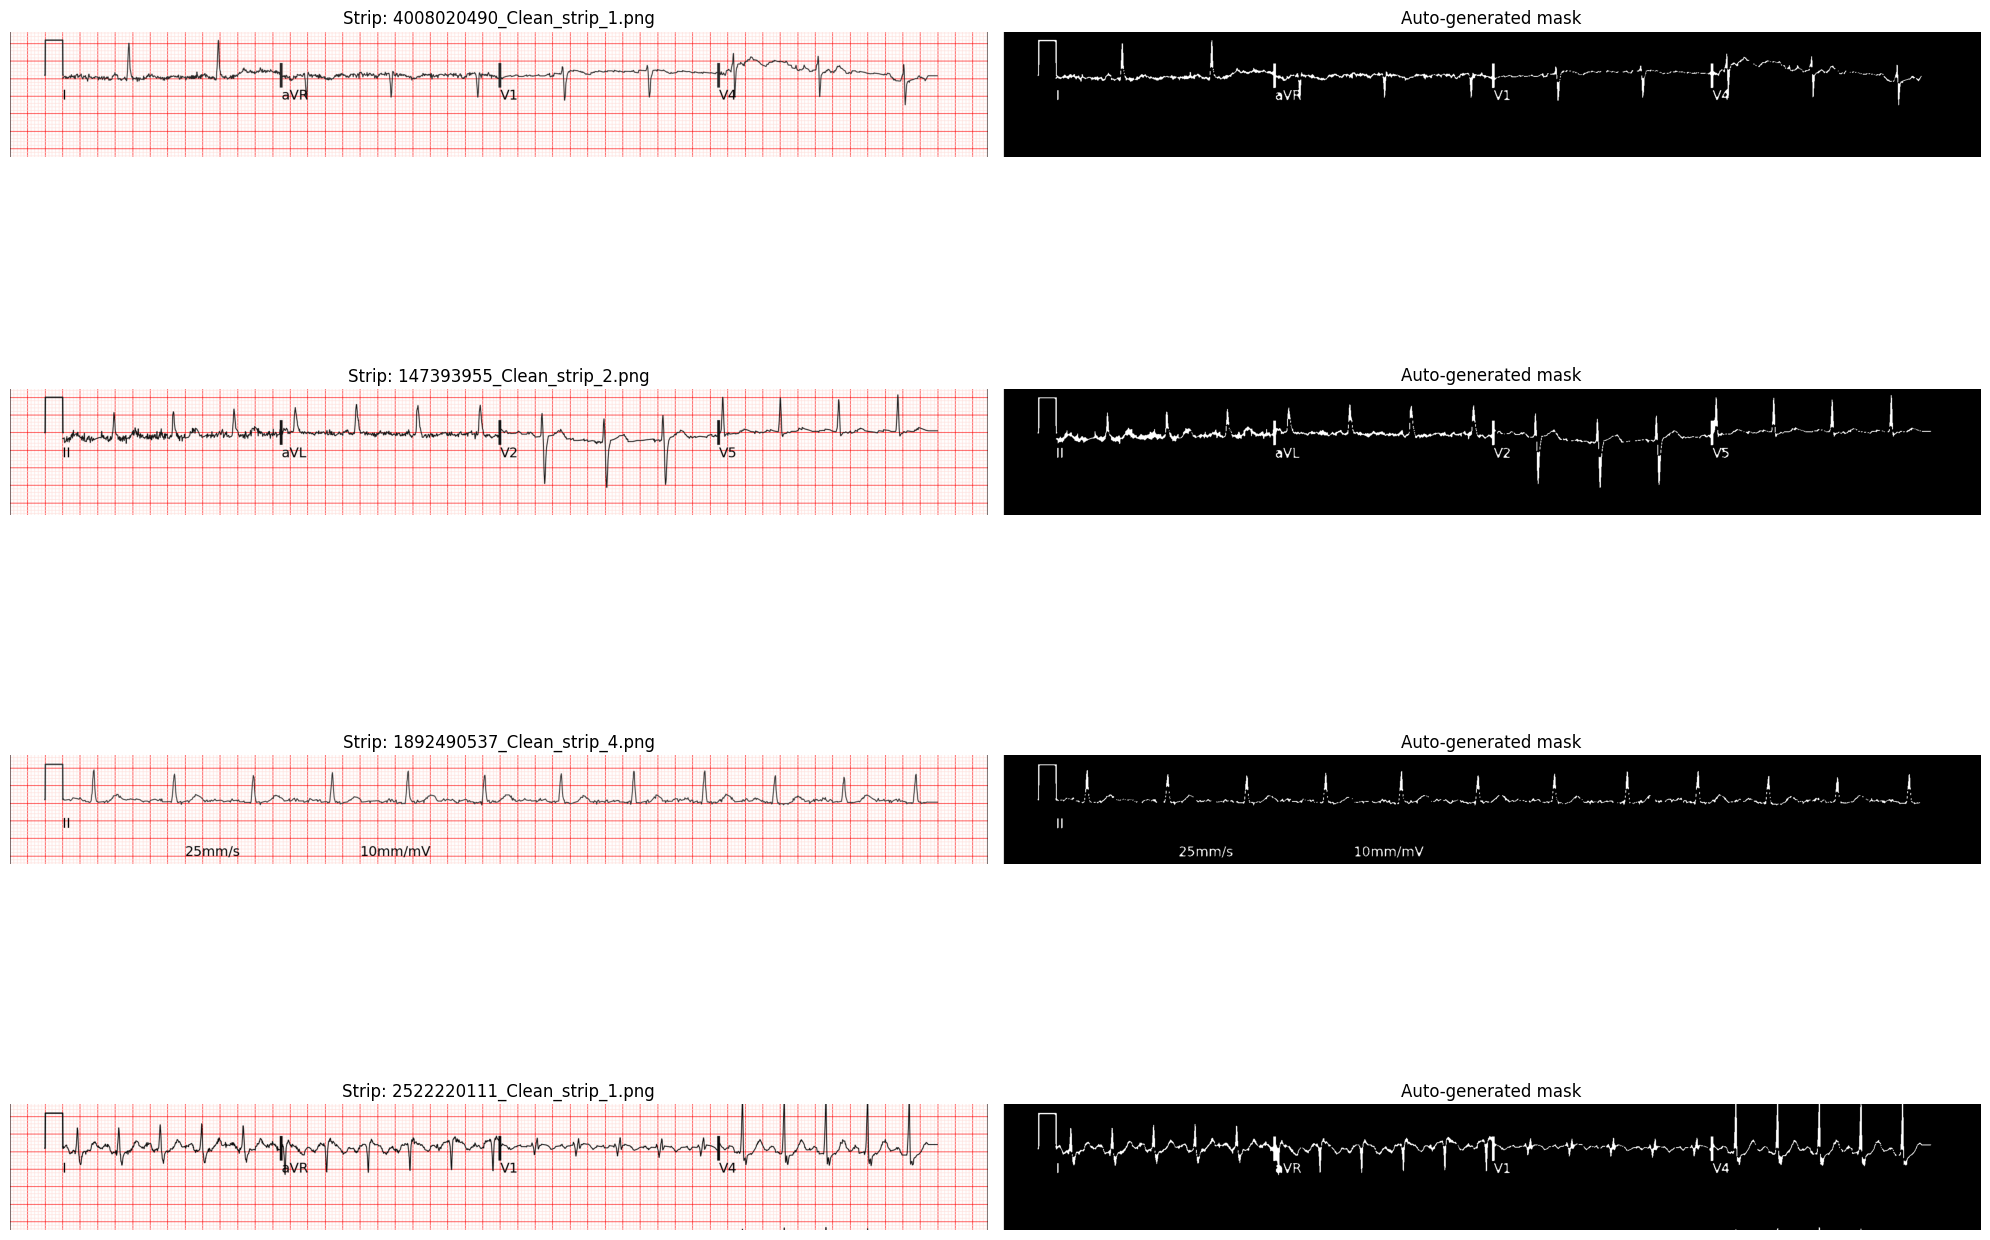

In [70]:
import matplotlib.pyplot as plt
import random

strip_paths = sorted(Path(STRIPS_DIR).glob('*.png'))
samples = random.sample(strip_paths, min(4, len(strip_paths)))

fig, axes = plt.subplots(len(samples), 2, figsize=(20, 4 * len(samples)))
if len(samples) == 1:
    axes = [axes]

for ax_row, sp in zip(axes, samples):
    img  = cv2.cvtColor(cv2.imread(str(sp)), cv2.COLOR_BGR2RGB)
    mask_path = Path(MASKS_DIR) / (sp.stem + '_mask.png')
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    ax_row[0].imshow(img);  ax_row[0].set_title(f'Strip: {sp.name}');  ax_row[0].axis('off')
    ax_row[1].imshow(mask, cmap='gray'); ax_row[1].set_title('Auto-generated mask'); ax_row[1].axis('off')

plt.tight_layout()
plt.show()

In [71]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.multiprocessing as mp
mp.set_start_method("fork", force=True)


class ECGStripDataset(Dataset):
    def __init__(self, strip_paths, masks_dir, transform=None):
        self.strip_paths = strip_paths
        self.masks_dir   = Path(masks_dir)
        self.transform   = transform

    def __len__(self):
        return len(self.strip_paths)

    def __getitem__(self, idx):
        sp   = self.strip_paths[idx]
        img  = cv2.cvtColor(cv2.imread(str(sp)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(self.masks_dir / (sp.stem + '_mask.png')), cv2.IMREAD_GRAYSCALE)

        # Binarize mask → 0 or 1
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented['image']
            mask = augmented['mask'].unsqueeze(0)   # add channel dim

        return img, mask


train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


all_strips = sorted(Path(STRIPS_DIR).glob('*.png'))
print(f'Total strips: {len(all_strips)}')

train_val, test_strips = train_test_split(all_strips, test_size=TEST_SPLIT, random_state=RANDOM_SEED)
train_strips, val_strips = train_test_split(train_val, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=RANDOM_SEED)

print(f'Train: {len(train_strips)} | Val: {len(val_strips)} | Test: {len(test_strips)}')

train_ds = ECGStripDataset(train_strips, MASKS_DIR, transform=train_transform)
val_ds   = ECGStripDataset(val_strips,   MASKS_DIR, transform=val_transform)
test_ds  = ECGStripDataset(test_strips,  MASKS_DIR, transform=val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=1,
    persistent_workers=True,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    persistent_workers=True,
    pin_memory=False,
)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print('DataLoaders ready')

Total strips: 2400
Train: 1920 | Val: 360 | Test: 120
DataLoaders ready


In [72]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=3,
    classes=1, # binary mask
    activation=None,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

Model parameters: 24,436,369


In [73]:
import torch
import torch.nn as nn


class BCEDiceLoss(nn.Module):
    """
    Combined Binary Cross-Entropy + Dice loss.
    BCE handles pixel-level accuracy; Dice handles class imbalance
    caused by the thin signal line vs large background.
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.smooth      = smooth
        self.bce         = nn.BCEWithLogitsLoss()

    def dice_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(2, 3))
        union        = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice         = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

    def forward(self, logits, targets):
        return self.bce_weight  * self.bce(logits, targets) + \
               self.dice_weight * self.dice_loss(logits, targets)


criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Reduce LR when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print('Loss, optimizer, and scheduler ready')

Loss, optimizer, and scheduler ready


In [74]:
def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs  = (torch.sigmoid(logits) > threshold).float()
    intersection = (probs * targets).sum(dim=(2, 3))
    union        = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    return ((2 * intersection + smooth) / (union + smooth)).mean().item()


def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    probs  = (torch.sigmoid(logits) > threshold).float()
    intersection = (probs * targets).sum(dim=(2, 3))
    union        = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()

In [75]:
from tqdm import tqdm

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}
best_val_loss = float('inf')


def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, masks in tqdm(loader, leave=False):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            loss   = criterion(logits, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_dice += dice_score(logits, masks)
            total_iou  += iou_score(logits, masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


for epoch in range(1, NUM_EPOCHS + 1):
    train_loader.num_workers = 0
    train_loss, _, _ = run_epoch(train_loader, training=True)
    val_loader.num_workers = 0
    val_loss, val_dice, val_iou = run_epoch(val_loader,   training=False)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved_marker = ' ✓ saved'
    else:
        saved_marker = ''

    print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Dice: {val_dice:.4f} | '
          f'IoU: {val_iou:.4f}{saved_marker}')

Epoch 001/50 | Train Loss: 0.6103 | Val Loss: 0.4845 | Dice: 0.7351 | IoU: 0.5823 ✓ saved


Epoch 002/50 | Train Loss: 0.4111 | Val Loss: 0.3253 | Dice: 0.8345 | IoU: 0.7169 ✓ saved


Epoch 003/50 | Train Loss: 0.2498 | Val Loss: 0.1817 | Dice: 0.8724 | IoU: 0.7746 ✓ saved


Epoch 004/50 | Train Loss: 0.1456 | Val Loss: 0.1168 | Dice: 0.8863 | IoU: 0.7966 ✓ saved


Epoch 005/50 | Train Loss: 0.1027 | Val Loss: 0.0904 | Dice: 0.8962 | IoU: 0.8126 ✓ saved


...

Epoch 046/50 | Train Loss: 0.0157 | Val Loss: 0.0462 | Dice: 0.9264 | IoU: 0.8633


Epoch 047/50 | Train Loss: 0.0153 | Val Loss: 0.0464 | Dice: 0.9263 | IoU: 0.8630


Epoch 048/50 | Train Loss: 0.0143 | Val Loss: 0.0464 | Dice: 0.9264 | IoU: 0.8632


Epoch 049/50 | Train Loss: 0.0134 | Val Loss: 0.0467 | Dice: 0.9260 | IoU: 0.8626


Epoch 050/50 | Train Loss: 0.0130 | Val Loss: 0.0469 | Dice: 0.9255 | IoU: 0.8617


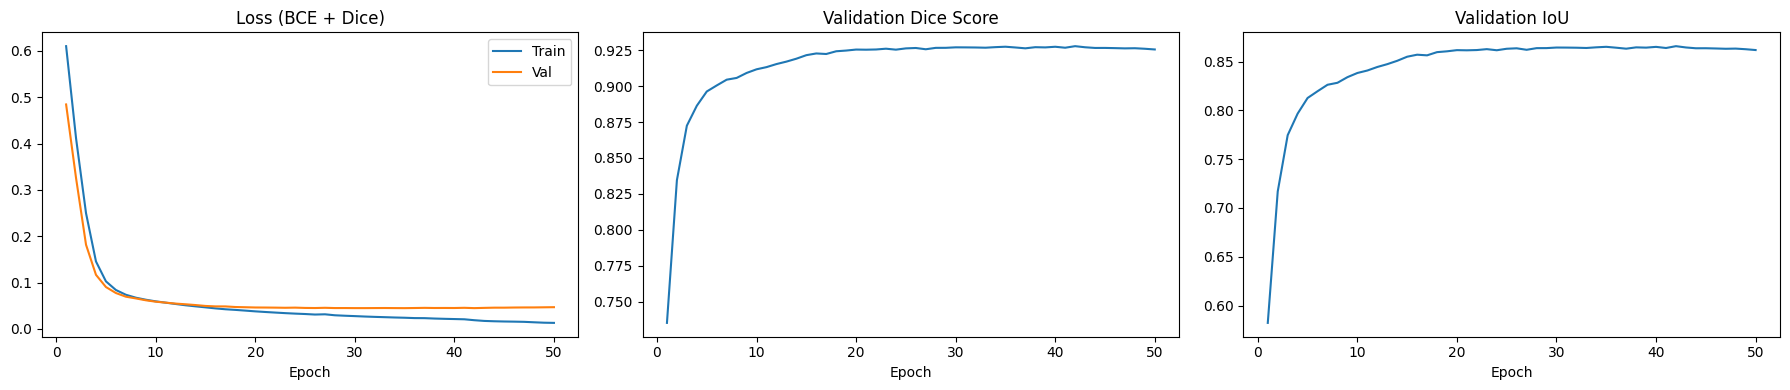

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['val_dice'])
axes[1].set_title('Validation Dice Score')
axes[1].set_xlabel('Epoch')

axes[2].plot(epochs, history['val_iou'])
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [77]:
# Load best model weights
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
test_loader.num_workers = 0
test_loss, test_dice, test_iou = run_epoch(test_loader, training=False)

print(f'Test Results')
print(f'  Loss : {test_loss:.4f}')
print(f'  Dice : {test_dice:.4f}')
print(f'  IoU  : {test_iou:.4f}')

Test Results
  Loss : 0.0459
  Dice : 0.9256
  IoU  : 0.8618


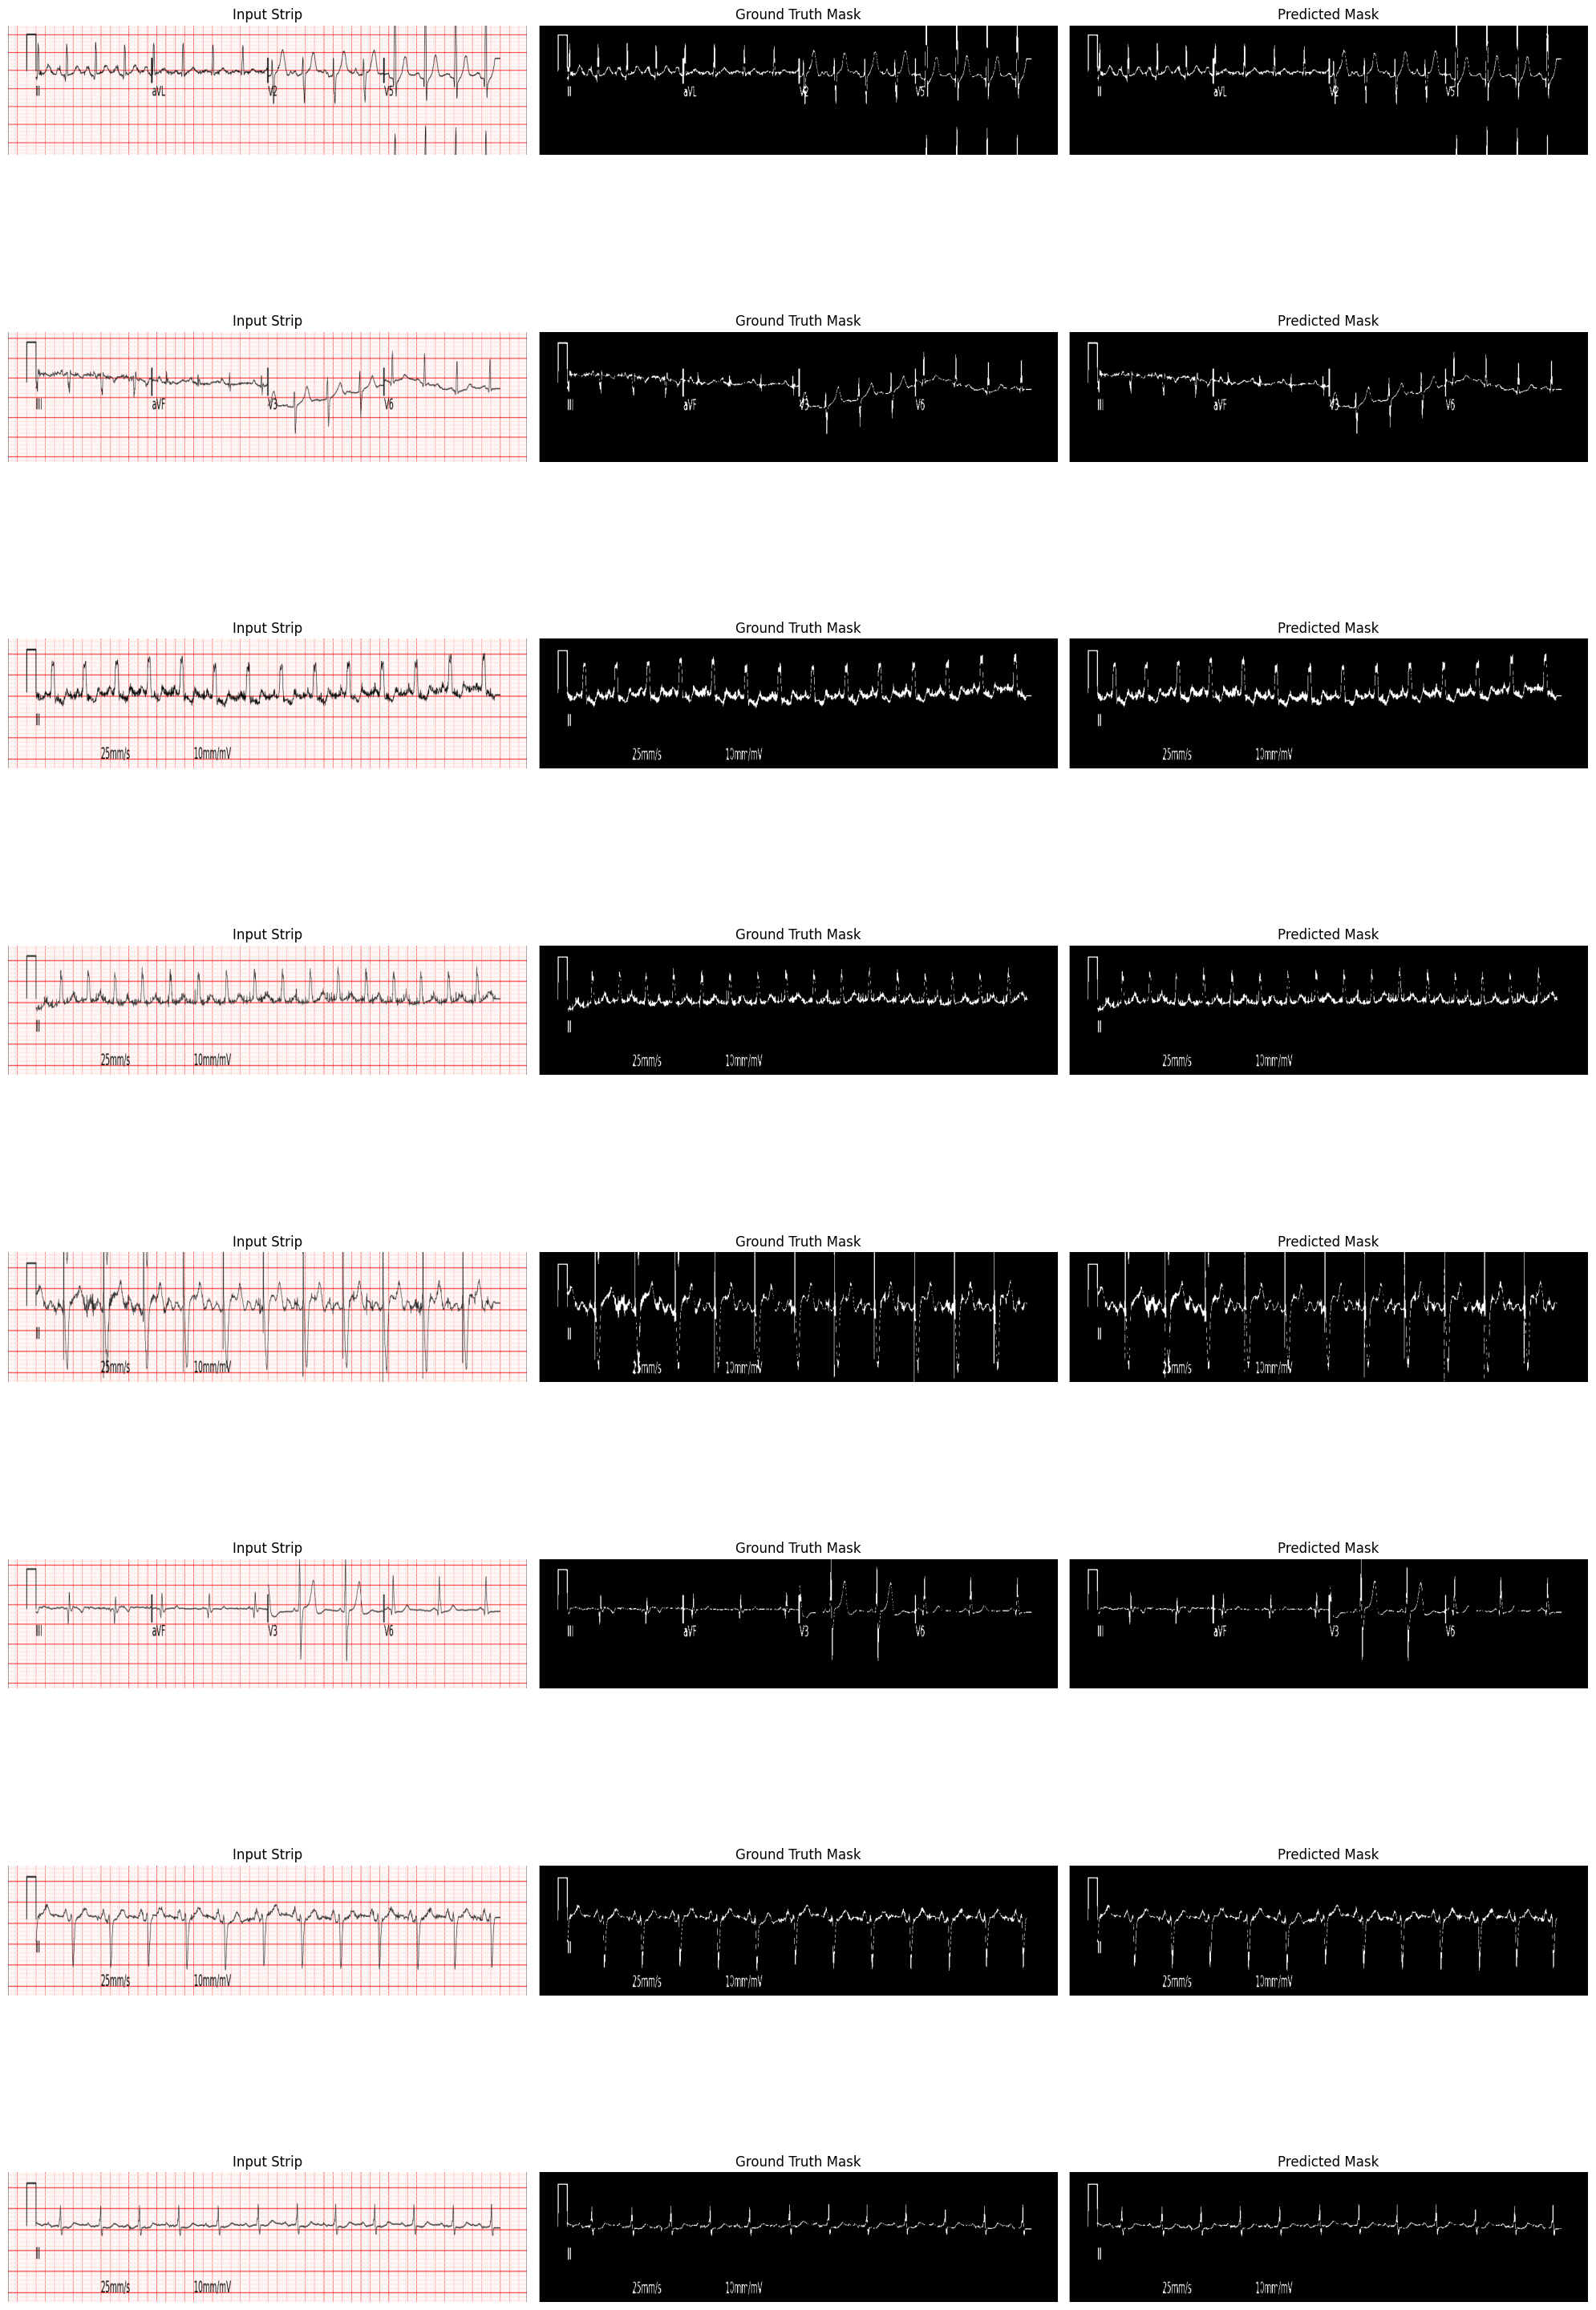

In [78]:
model.eval()
imgs, masks = next(iter(test_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    logits = model(imgs)
    preds  = (torch.sigmoid(logits) > 0.5).float()

# Denormalize to display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

n_show = min(10, imgs.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(20, 4 * n_show))

for i in range(n_show):
    img_disp  = (imgs[i].cpu() * std + mean).permute(1,2,0).clamp(0,1).numpy()
    mask_disp = masks[i,0].cpu().numpy()
    pred_disp = preds[i,0].cpu().numpy()

    axes[i][0].imshow(img_disp);              axes[i][0].set_title('Input Strip');      axes[i][0].axis('off')
    axes[i][1].imshow(mask_disp, cmap='gray'); axes[i][1].set_title('Ground Truth Mask'); axes[i][1].axis('off')
    axes[i][2].imshow(pred_disp, cmap='gray'); axes[i][2].set_title('Predicted Mask');   axes[i][2].axis('off')

plt.tight_layout()
plt.show()